alpha_schedule:
  _target_: schedulers.ConstantScheduler
  use_warmup: true
  warmup_steps: null
  initial_value: 1
  final_value: 0.01
experiment:
  name: moe_wikitext
model:
  d_model: 256
  num_layers: 3
  num_experts: 4
  top_k: 2
  padding_idx: 0
training:
  dataset_name: wikitext-2-v1
  batch_size: 32
  seq_len: 256
  num_workers: 0
  epochs: 3
  lr: 0.0003
  log_interval: 500
  total_steps: 10000
  gpu_id: 3
mlflow:
  tracking_uri: file:./mlruns
  experiment_name: wikitext103_moe



/tmp/ipykernel_1811244/3967823893.py:14: UserWarning: 
The version_base parameter is not specified.
Please specify a compatability version level, or None.
Will assume defaults for version 1.1
  with initialize(config_path="."):
/home/vasilevpa/fl1/Federated-Mixture-of-Experts-with-Personalized-Weighting/.venv/lib/python3.12/site-packages/hydra/_internal/defaults_list.py:251: UserWarning: In 'configs/base.yaml': Defaults list is missing `_self_`. See https://hydra.cc/docs/1.2/upgrades/1.0_to_1.1/default_composition_order for more information
  warnings.warn(msg, UserWarning)


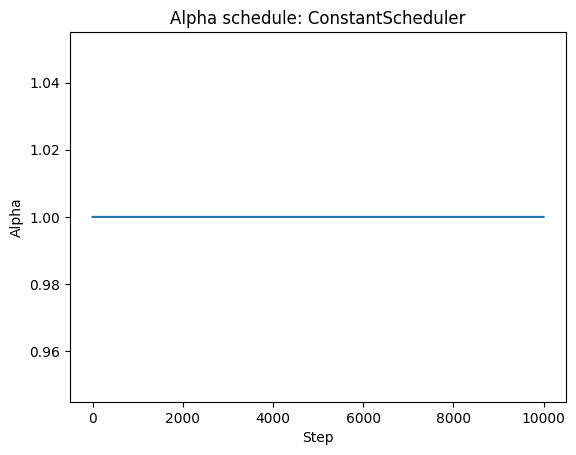

In [7]:
from hydra import initialize, compose
from omegaconf import OmegaConf
import matplotlib.pyplot as plt
import torch
from schedulers import ConstantScheduler, CosineScheduler, ExponentialScheduler

SCHEDULERS = {
    "ConstantScheduler": ConstantScheduler,
    "CosineScheduler": CosineScheduler,
    "ExponentialScheduler": ExponentialScheduler,
}

# Укажи путь к конфигам
with initialize(config_path="."):
    cfg = compose(config_name="configs/base.yaml")

cfg = cfg.configs
yamlik = OmegaConf.to_yaml(cfg)
print(yamlik)
sched_cfg = cfg.alpha_schedule
SchedulerCls = SCHEDULERS[sched_cfg._target_.split(".")[-1]]

scheduler = SchedulerCls(
    total_steps=cfg.training.total_steps,
    use_warmup=sched_cfg.use_warmup,
    warmup_steps=sched_cfg.warmup_steps,
    initial_value=sched_cfg.initial_value,
    final_value=sched_cfg.final_value,
)

values = [scheduler.step() for _ in range(cfg.training.total_steps)]

plt.plot(values)
plt.xlabel("Step")
plt.ylabel("Alpha")
plt.title(f"Alpha schedule: {SchedulerCls.__name__}")
plt.show()
